In [122]:
import numpy as np
import matplotlib.pyplot as plt
import verde as vd
import harmonica as hm
import boule as bl
from numpy.linalg import inv
import spherical as sph

51182


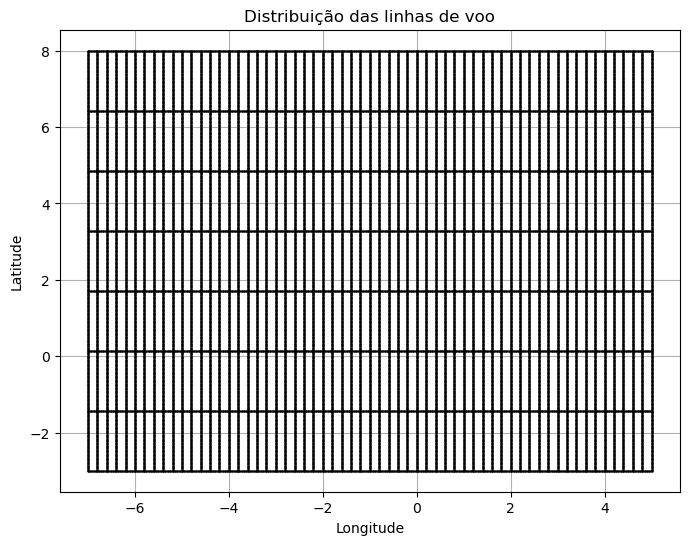

In [123]:
ellipsoid = bl.WGS84
 
region_airbone = [-7, 5, -3, 8]  

spacing_1 = (0.015, 0.2) 
coordinates_1 = vd.grid_coordinates(region=region_airbone, spacing=spacing_1, extra_coords=ellipsoid.mean_radius + 500)


spacing_2 = (1.5, 0.015) 
coordinates_2 = vd.grid_coordinates(region=region_airbone, spacing=spacing_2, extra_coords=ellipsoid.mean_radius + 500)


coordinates = np.concatenate((coordinates_1[0].ravel(), coordinates_2[0].ravel())), \
              np.concatenate((coordinates_1[1].ravel(), coordinates_2[1].ravel())), \
              np.concatenate((coordinates_1[2].ravel(), coordinates_2[2].ravel()))

print(coordinates[0].size)
plt.figure(figsize=(8, 6))
plt.plot(coordinates[0], coordinates[1], ".k", markersize=1)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Distribuição das linhas de voo")
plt.grid()
plt.show()

In [124]:
inclination, declination = 30, 20
noise_level = 0.05
# Syntetic dike

dike_size = 100
dike = sph.profile_points((1,-3), (5,1), dike_size, ellipsoid.mean_radius - 4.0e4)
dike_2 =sph.profile_points((6,6), (0,8), dike_size, ellipsoid.mean_radius - 4.0e4)

# Syntetic dipoles
n_dipoles = 4
dipoles = tuple(c.ravel() for c in vd.scatter_points(region= region_airbone, size= n_dipoles, extra_coords= ellipsoid.mean_radius - 2e4, random_state=2))

#Data

magnetic_field = sph.dipole_magnetic_spherical(coordinates,
    dipoles,
magnetic_moments = hm.magnetic_angles_to_vec(
    np.full(n_dipoles, 1e12),  
    np.full(n_dipoles, inclination),  
    np.full(n_dipoles, declination)   
)
)
magnetic_anomaly = hm.total_field_anomaly(magnetic_field, inclination, declination)

magnetic_moments_dike = hm.magnetic_angles_to_vec(
    np.full(dike_size, -1e11),  
    np.full(dike_size, inclination),  
    np.full(dike_size, declination)   
)


magnetic_field = sph.dipole_magnetic_spherical(coordinates, dike, magnetic_moments_dike)

magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

magnetic_field = sph.dipole_magnetic_spherical(coordinates, dike_2, magnetic_moments_dike)

magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)


# Add noise and the base level
magnetic_anomaly += np.random.default_rng(42).normal(
    0, noise_level, size=magnetic_anomaly.shape
)

(np.float64(-7.6), np.float64(5.6), np.float64(-3.55), np.float64(8.55))

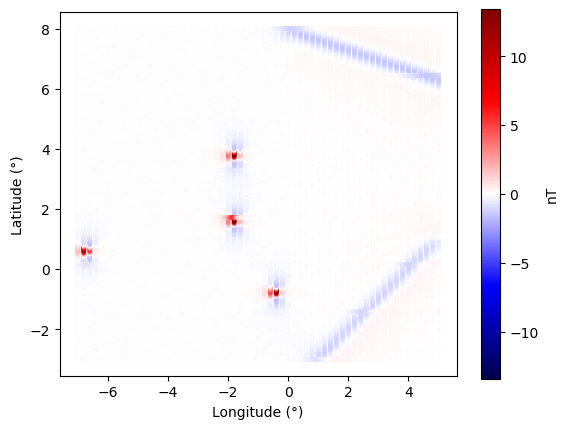

In [125]:
scale = vd.maxabs(magnetic_anomaly)
plt.scatter(coordinates[0], coordinates[1],  c = magnetic_anomaly, s = 5,cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')
plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
plt.axis("scaled")

In [126]:
equivalent_layer = (
    coordinates[0],
    coordinates[1],
    coordinates[2] - 2e4
)



damping = 1e-5
eqs_inc = 90
eqs_dec = 0
eqs_dipole_unit = hm.magnetic_angles_to_vec(1,eqs_inc, eqs_dec)

In [127]:
window_size = 4
_, source_indices = vd.rolling_window(equivalent_layer, size=window_size, spacing=window_size / 2)
_, data_indices = vd.rolling_window(coordinates, size=window_size, spacing=window_size / 2)
source_indices = [i[0] for i in source_indices.ravel()]
data_indices = [i[0] for i in data_indices.ravel()]

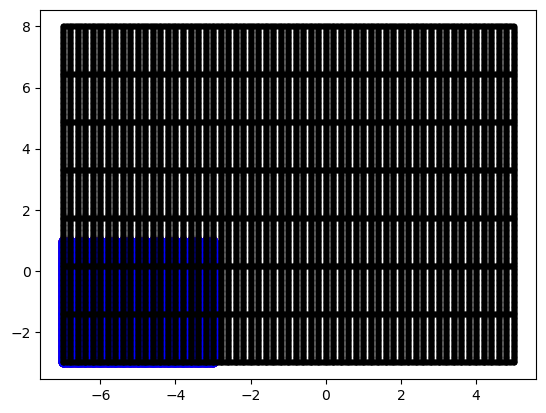

In [128]:
i = 0

data_coord = tuple(c[data_indices[i]] for c in coordinates)
source_coord = tuple(c[source_indices[i]] for c in equivalent_layer)

plt.plot(*data_coord[:2], "or")
plt.plot(*source_coord[:2], "ob")
plt.plot(*coordinates[:2], ".k")

In [129]:
def compute_magnetic_anomaly(grid_coord, inclination, declination, dipole_data, moment_amplitudes):
    
    moments = [
        hm.magnetic_angles_to_vec(amplitude, inclination, declination)
        for amplitude in moment_amplitudes
    ]

    grided_magnetic_anomaly = np.zeros(grid_coord[0].shape)


    dipole_latitudes, dipole_longitudes, dipole_radii = dipole_data

    for lat, lon, r, moment in zip(dipole_latitudes.flatten(), dipole_longitudes.flatten(), dipole_radii.flatten(), moments):
        dipole_coordinates = np.array([lat, lon, r])
        
        magnetic_field = sph.dipole_magnetic_spherical(
            grid_coord,
            dipoles=dipole_coordinates,
            magnetic_moments=moment
        )
        
        grided_magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

    return grided_magnetic_anomaly

In [130]:
grid_coord = tuple(c.ravel() for c in vd.grid_coordinates(region_airbone, shape=(150,150), extra_coords=ellipsoid.mean_radius + 200))

grided_dd_anomaly = compute_magnetic_anomaly(grid_coord, inclination, declination, dike, np.full(dike_size, -1e11))
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, dike_2, np.full(dike_size, -1e11))
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, dipoles, np.full(n_dipoles ,1e12))

In [131]:
def fit(coordinates, data, eqs_source_coords, damping, eqs_inc, eqs_dec, inclination_main_field, declination_main_field):
    A = sph.jacobian(
        coordinates, 
        eqs_source_coords,
        eqs_inc, eqs_dec,
        inclination_main_field, declination_main_field
    )
    eqs_dipole_moment_amplitude = sph.calculate_coefficients(
        data, A, damping=damping,
    )
    return eqs_dipole_moment_amplitude

In [132]:
rmses = []
residuals = magnetic_anomaly.copy()
scale = vd.maxabs(magnetic_anomaly)
dipole_moment_amp = np.zeros_like(equivalent_layer[0])

predicted_total_field_grid = grided_dd_anomaly.copy()

window_indices = list(range(len(data_indices)))
np.random.shuffle(window_indices)
for i in window_indices:
    data_coord = tuple(c[data_indices[i]] for c in coordinates)
    source_coord = tuple(c[source_indices[i]] for c in equivalent_layer)
    
    eqs_dipole_moment_amp = fit(
        data_coord,
        residuals[data_indices[i]],
        source_coord,
        damping,
        eqs_inc,
        eqs_dec,
        inclination,
        declination
    )
    dipole_moment_amp[source_indices[i]] += eqs_dipole_moment_amp
    eqs_dipole_moment =  np.array( hm.magnetic_angles_to_vec(
    np.full(eqs_dipole_moment_amp.size, 1),  
    np.full(eqs_dipole_moment_amp.size, inclination),  
    np.full(eqs_dipole_moment_amp.size, declination)   
))


    predicted_total_field_anomaly = hm.total_field_anomaly(
        sph.dipole_magnetic_spherical(coordinates, source_coord, eqs_dipole_moment),
          inclination, declination)
    residuals -= predicted_total_field_anomaly
    
    
    predicted_total_field_grid -= hm.total_field_anomaly(
        sph.dipole_magnetic_spherical(grid_coord, source_coord, eqs_dipole_moment),
        inclination, declination,
    )


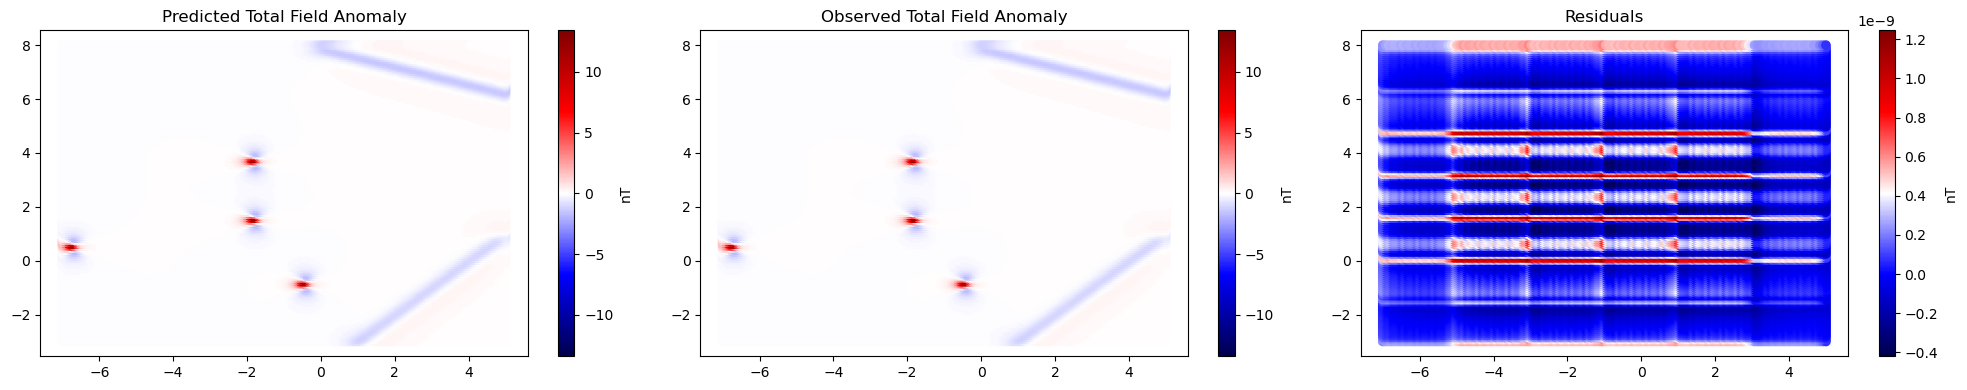

In [133]:

plt.figure(figsize=(20,4))
plt.subplot(1,3,2)
plt.title("Observed Total Field Anomaly")
plt.scatter(
    *grid_coord[:2], c=grided_dd_anomaly, cmap="seismic", vmin=-scale, vmax=scale
)
plt.colorbar(label='nT')
plt.subplot(1,3,1)
plt.title("Predicted Total Field Anomaly")
plt.scatter(
    *grid_coord[:2], c=predicted_total_field_grid, cmap="seismic", vmin=-scale, vmax=scale
)
plt.colorbar(label='nT')
diff_grid_tfa = grided_dd_anomaly - predicted_total_field_grid
rmse_grid_tfa = np.sqrt(np.square(diff_grid_tfa).mean())
plt.subplot(1,3,3)
plt.title('Residuals')
plt.scatter(
    *grid_coord[:2], c=diff_grid_tfa, cmap="seismic")
plt.colorbar(label='nT')
plt.tight_layout()

/tmp/ipykernel_161061/2035355274.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.18, 1, 1])


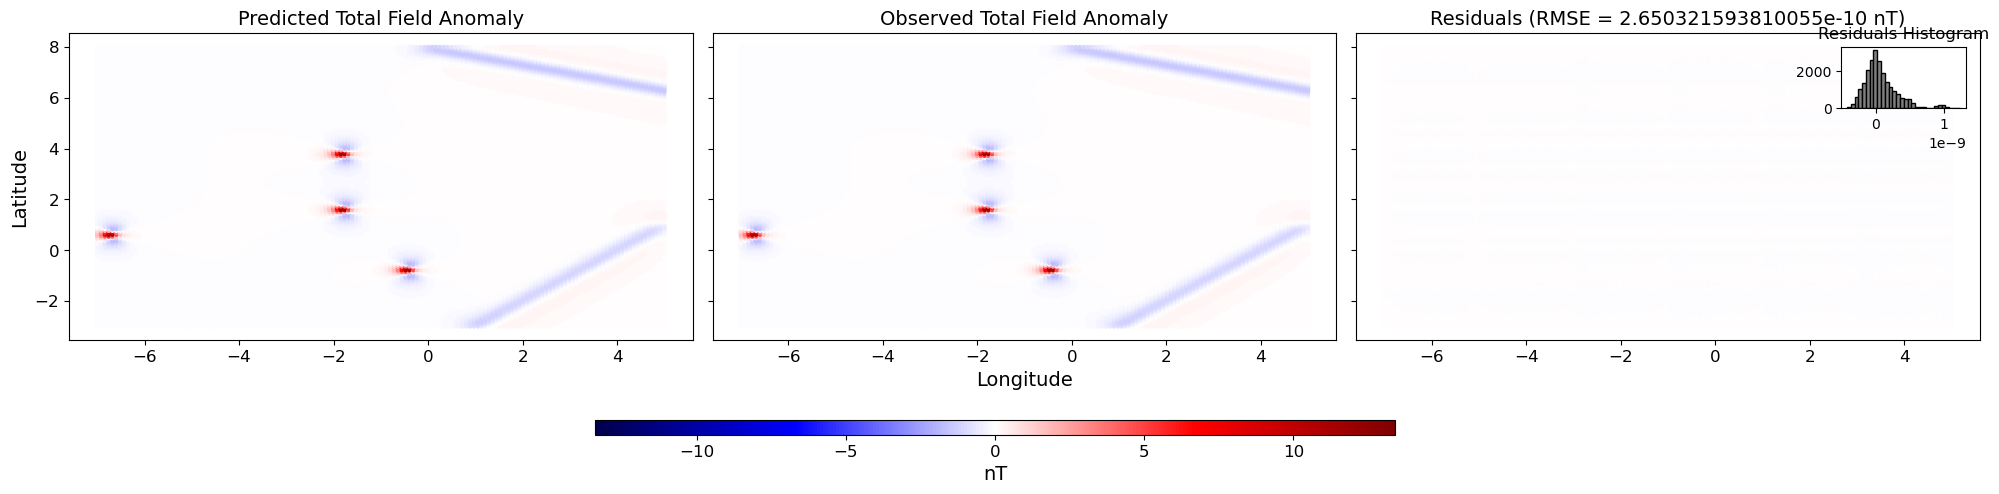

In [134]:


# Cálculo dos resíduos e RMSE
diff_grid_tfa = grided_dd_anomaly - predicted_total_field_grid
rmse_grid_tfa = np.sqrt(np.square(diff_grid_tfa).mean())

fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)

scale = vd.maxabs(magnetic_anomaly)
vmin, vmax = -scale, scale
cmap = "seismic"
fontsize = 14

# Plot 1: Predito
sc = axes[0].scatter(*grid_coord[:2], c=predicted_total_field_grid, cmap=cmap,
                     vmin=vmin, vmax=vmax, s=5)
axes[0].set_title("Predicted Total Field Anomaly", fontsize=fontsize)
axes[0].set_ylabel("Latitude", fontsize=fontsize)
axes[0].tick_params(labelsize=fontsize - 2)

# Plot 2: Observado
axes[1].scatter(*grid_coord[:2], c=grided_dd_anomaly, cmap=cmap,
                vmin=vmin, vmax=vmax, s=5)
axes[1].set_title("Observed Total Field Anomaly", fontsize=fontsize)
axes[1].set_xlabel("Longitude", fontsize=fontsize)
axes[1].tick_params(labelsize=fontsize - 2)

# Plot 3: Resíduos
axes[2].scatter(*grid_coord[:2], c=diff_grid_tfa, cmap=cmap,
                vmin=vmin, vmax=vmax, s=5)
axes[2].set_title(f"Residuals (RMSE = {rmse_grid_tfa} nT)", fontsize=fontsize)
axes[2].tick_params(labelsize=fontsize - 2)

# Adiciona histograma dos resíduos dentro do plot de resíduos
inset_ax = inset_axes(axes[2], width="20%", height="20%", loc="upper right",
                      borderpad=1)
inset_ax.hist(diff_grid_tfa, bins=30, color="gray", edgecolor="black")
inset_ax.set_title("Residuals Histogram", fontsize=fontsize - 2)
inset_ax.tick_params(labelsize=fontsize - 4)

# Barra de cor horizontal compartilhada
cbar_ax = fig.add_axes([0.3, 0.12, 0.4, 0.03])
cbar = fig.colorbar(sc, cax=cbar_ax, orientation='horizontal')
cbar.set_label("nT", fontsize=fontsize)
cbar.ax.tick_params(labelsize=fontsize - 2)

# Ajuste do layout
plt.tight_layout(rect=[0, 0.18, 1, 1])
plt.show()


/tmp/ipykernel_161061/1513052470.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.18, 1, 1])


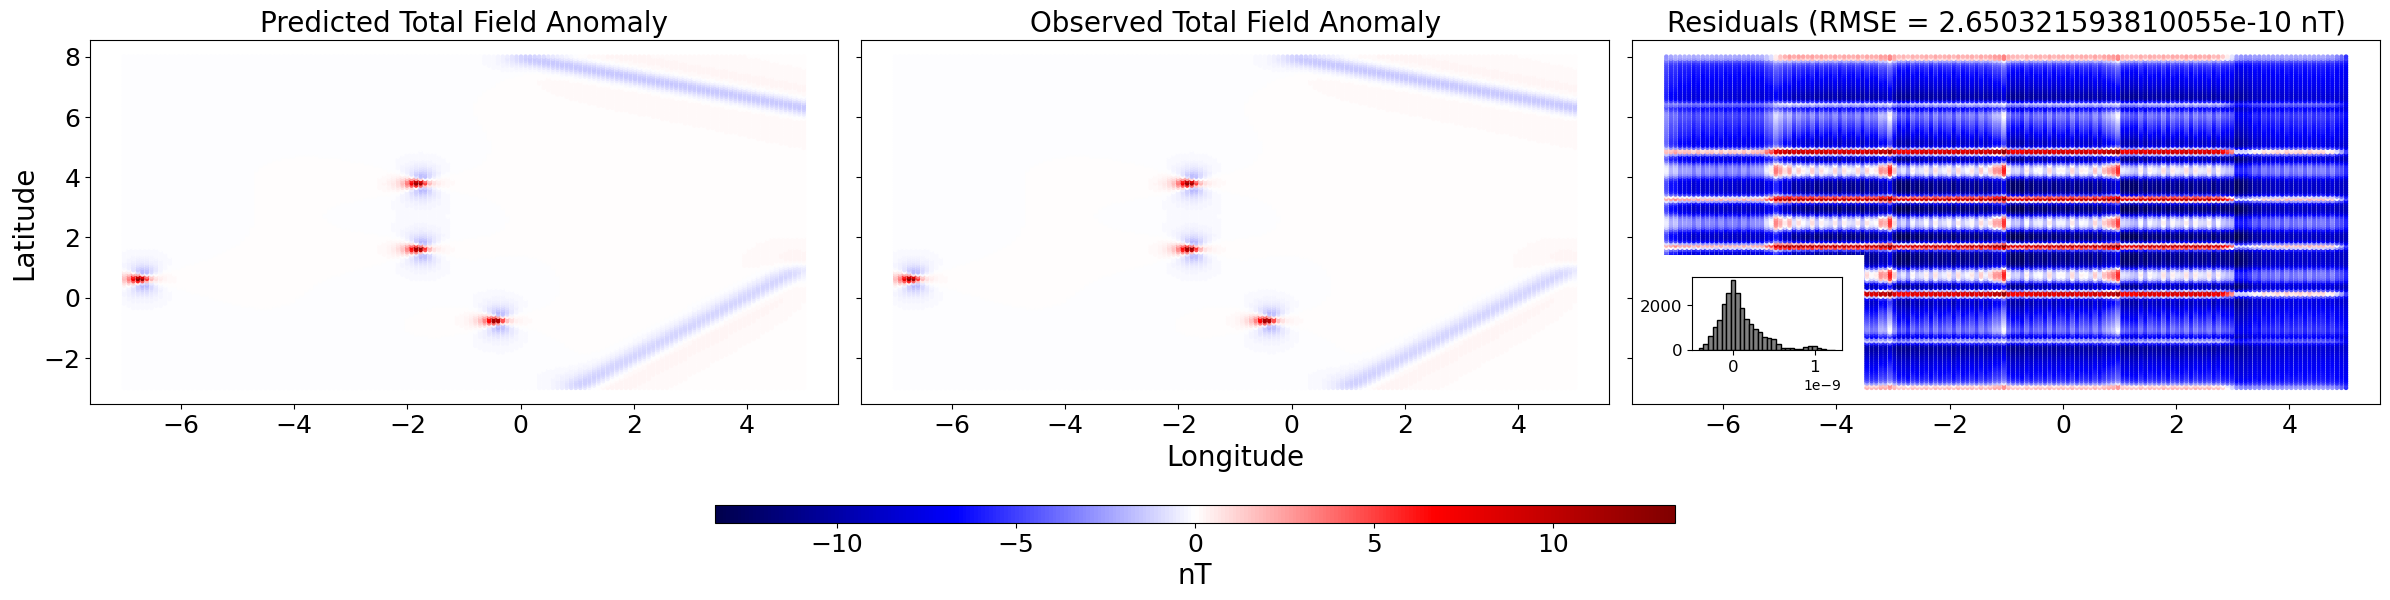

In [144]:
fontsize = 20  # Aumentado
tick_fontsize = fontsize - 2
inset_fontsize = fontsize - 6

fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharex=True, sharey=True)

ax.set_aspect("equal")
sc = axes[0].scatter(*grid_coord[:2], c=predicted_total_field_grid, cmap=cmap,
                     vmin=vmin, vmax=vmax, s=5)
axes[0].set_title("Predicted Total Field Anomaly", fontsize=fontsize)
axes[0].set_ylabel("Latitude", fontsize=fontsize)
axes[0].tick_params(labelsize=tick_fontsize)

axes[1].scatter(*grid_coord[:2], c=grided_dd_anomaly, cmap=cmap,
                vmin=vmin, vmax=vmax, s=5)
axes[1].set_title("Observed Total Field Anomaly", fontsize=fontsize)
axes[1].set_xlabel("Longitude", fontsize=fontsize)
axes[1].tick_params(labelsize=tick_fontsize)

axes[2].scatter(*grid_coord[:2], c=diff_grid_tfa, cmap=cmap, s=5)
axes[2].set_title(f"Residuals (RMSE = {rmse_grid_tfa} nT)", fontsize=fontsize)
axes[2].tick_params(labelsize=tick_fontsize)

# Retângulo de fundo
rect = patches.Rectangle((0.01, 0.01), 0.3, 0.4,
                         transform=axes[2].transAxes,
                         color='white', zorder=3, linewidth=0)
axes[2].add_patch(rect)

# Histograma (inset)
inset_ax = axes[2].inset_axes([0.08, 0.15, 0.2, 0.2])
inset_ax.hist(diff_grid_tfa, bins=30, color="gray", edgecolor="black")
inset_ax.tick_params(labelsize=inset_fontsize-2)

# Barra de cores
cbar_ax = fig.add_axes([0.3, 0.12, 0.4, 0.03])
cbar = fig.colorbar(sc, cax=cbar_ax, orientation='horizontal')
cbar.set_label("nT", fontsize=fontsize)
cbar.ax.tick_params(labelsize=tick_fontsize)

# Layout e salvamento
plt.tight_layout(rect=[0, 0.18, 1, 1])
plt.savefig('total_field_anomaly_inversion-gb.png', dpi=300, format="png", bbox_inches="tight")
plt.show()

/tmp/ipykernel_161061/651495389.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.18, 1, 1])


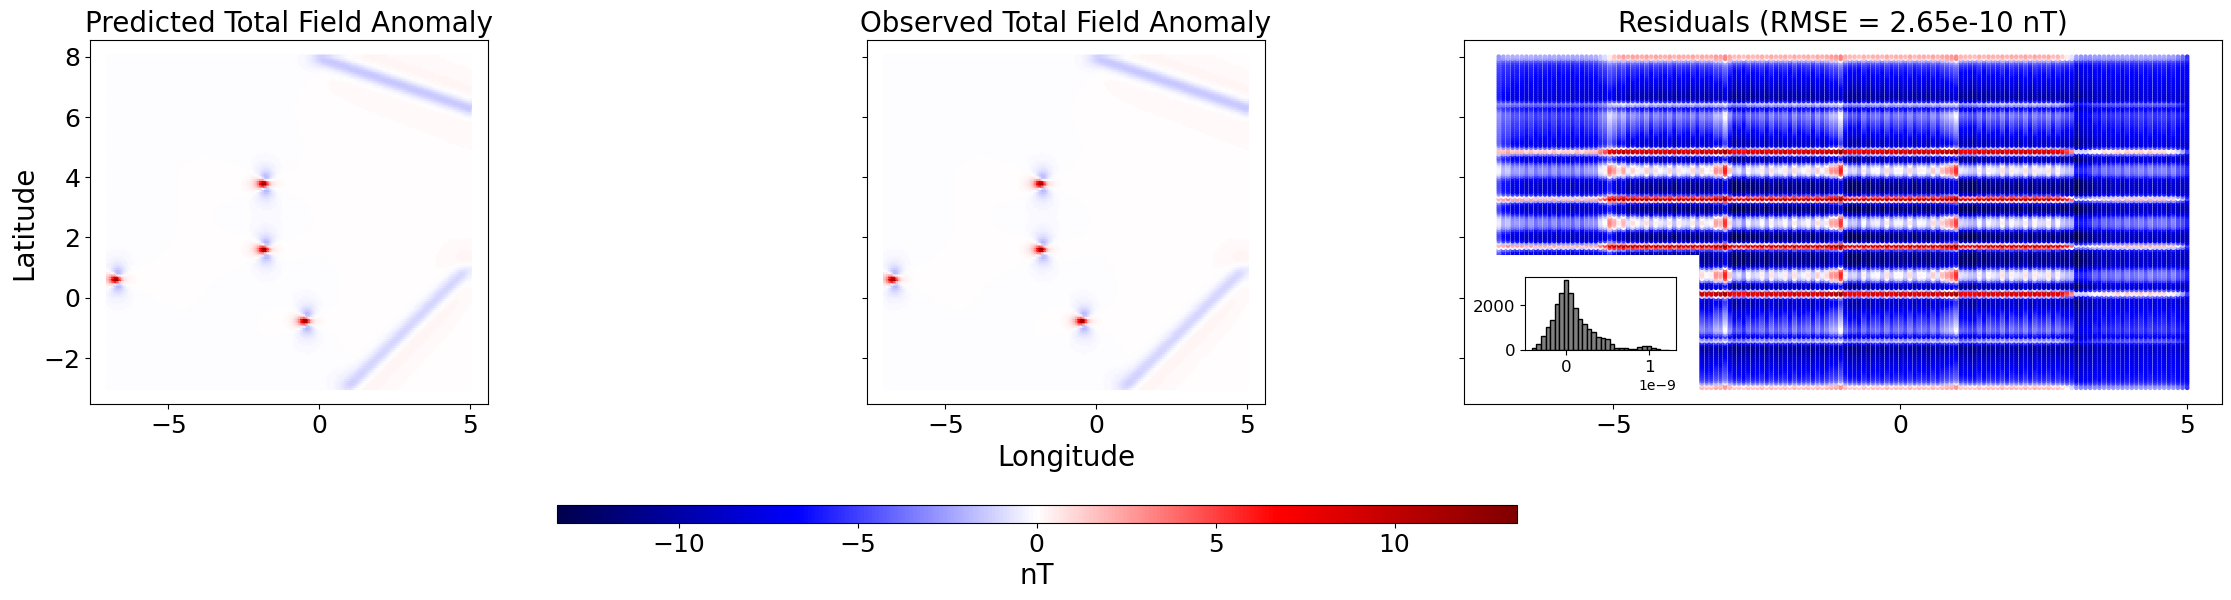

In [148]:
fontsize = 20
tick_fontsize = fontsize - 2
inset_fontsize = fontsize - 6

fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharex=True, sharey=True)

# Plot 1 - Predicted
sc = axes[0].scatter(*grid_coord[:2], c=predicted_total_field_grid, cmap=cmap,
                     vmin=vmin, vmax=vmax, s=5)
axes[0].set_title("Predicted Total Field Anomaly", fontsize=fontsize)
axes[0].set_ylabel("Latitude", fontsize=fontsize)
axes[0].tick_params(labelsize=tick_fontsize)
axes[0].set_aspect("equal")  # Mantém mapa com escala 1:1

# Plot 2 - Observed
axes[1].scatter(*grid_coord[:2], c=grided_dd_anomaly, cmap=cmap,
                vmin=vmin, vmax=vmax, s=5)
axes[1].set_title("Observed Total Field Anomaly", fontsize=fontsize)
axes[1].set_xlabel("Longitude", fontsize=fontsize)
axes[1].tick_params(labelsize=tick_fontsize)
axes[1].set_aspect("equal")  # Mantém mapa com escala 1:1

# Plot 3 - Residuals (sem aspecto fixo)
axes[2].scatter(*grid_coord[:2], c=diff_grid_tfa, cmap=cmap, s=5)
axes[2].set_title(f"Residuals (RMSE = {rmse_grid_tfa:.2e} nT)", fontsize=fontsize)
axes[2].tick_params(labelsize=tick_fontsize)
# NÃO usar set_aspect aqui — deixa livre

# Retângulo branco no fundo
rect = patches.Rectangle((0.01, 0.01), 0.3, 0.4,
                         transform=axes[2].transAxes,
                         color='white', zorder=3, linewidth=0)
axes[2].add_patch(rect)

# Inset com histograma
inset_ax = axes[2].inset_axes([0.08, 0.15, 0.2, 0.2])
inset_ax.hist(diff_grid_tfa, bins=30, color="gray", edgecolor="black")
inset_ax.tick_params(labelsize=inset_fontsize - 2)

# Barra de cores central
cbar_ax = fig.add_axes([0.3, 0.12, 0.4, 0.03])
cbar = fig.colorbar(sc, cax=cbar_ax, orientation='horizontal')
cbar.set_label("nT", fontsize=fontsize)
cbar.ax.tick_params(labelsize=tick_fontsize)

# Layout final
plt.tight_layout(rect=[0, 0.18, 1, 1])
plt.savefig('total_field_anomaly_inversion-gb.png', dpi=300, format="png", bbox_inches="tight")
plt.show()

/tmp/ipykernel_161061/1266749520.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


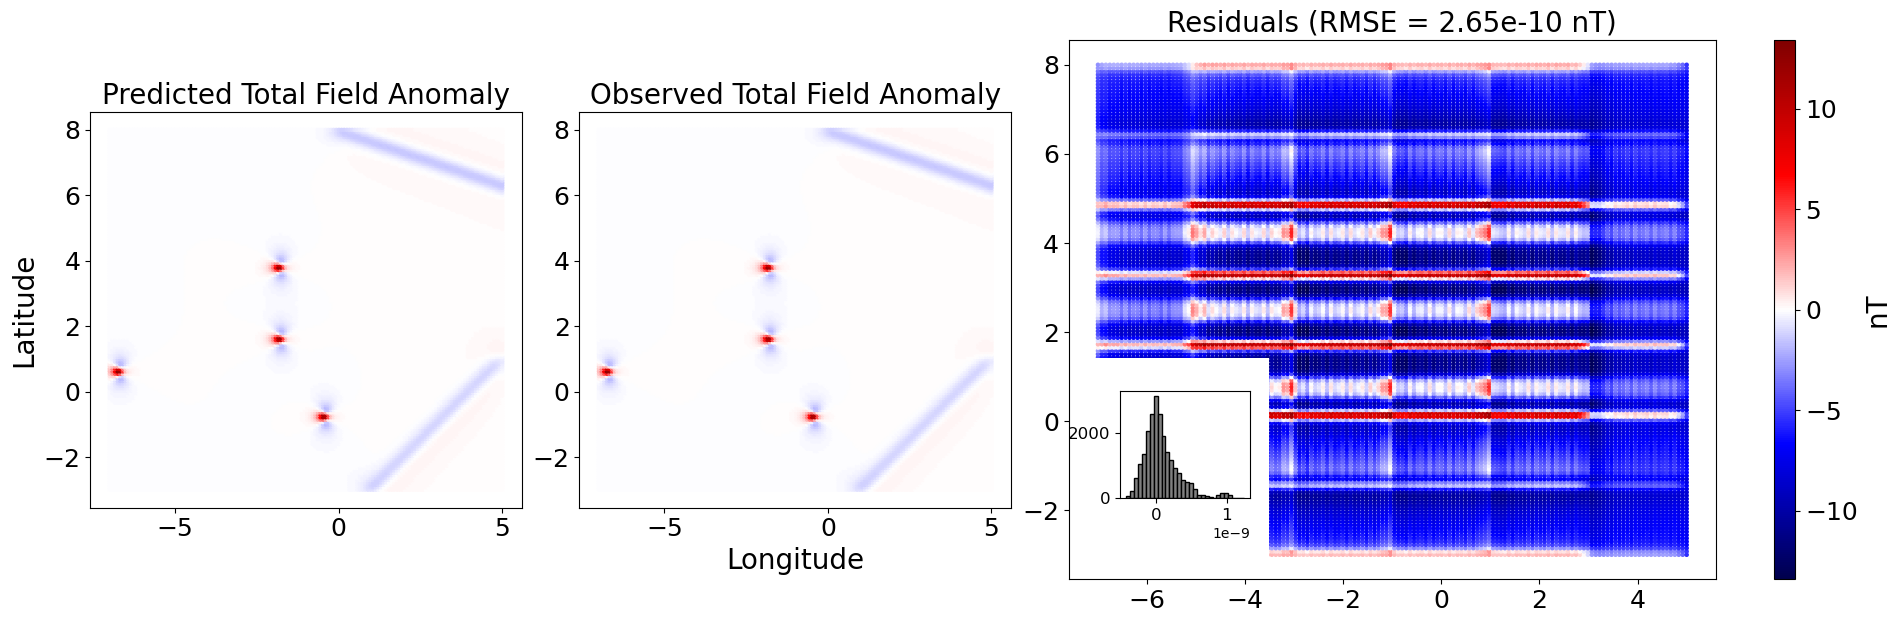

In [149]:
import matplotlib.pyplot as plt
from matplotlib import gridspec, patches

fontsize = 20
tick_fontsize = fontsize - 2
inset_fontsize = fontsize - 6

fig = plt.figure(figsize=(22, 7))
gs = gridspec.GridSpec(1, 4, width_ratios=[1, 1, 1.5, 0.05], wspace=0.15)

# Subplot 1 - Predicted
ax1 = fig.add_subplot(gs[0])
sc = ax1.scatter(*grid_coord[:2], c=predicted_total_field_grid, cmap=cmap,
                 vmin=vmin, vmax=vmax, s=5)
ax1.set_title("Predicted Total Field Anomaly", fontsize=fontsize)
ax1.set_ylabel("Latitude", fontsize=fontsize)
ax1.tick_params(labelsize=tick_fontsize)
ax1.set_aspect("equal")

# Subplot 2 - Observed
ax2 = fig.add_subplot(gs[1], sharex=ax1, sharey=ax1)
ax2.scatter(*grid_coord[:2], c=grided_dd_anomaly, cmap=cmap,
            vmin=vmin, vmax=vmax, s=5)
ax2.set_title("Observed Total Field Anomaly", fontsize=fontsize)
ax2.set_xlabel("Longitude", fontsize=fontsize)
ax2.tick_params(labelsize=tick_fontsize)
ax2.set_aspect("equal")

# Subplot 3 - Residuals
ax3 = fig.add_subplot(gs[2])
ax3.scatter(*grid_coord[:2], c=diff_grid_tfa, cmap=cmap, s=5)
ax3.set_title(f"Residuals (RMSE = {rmse_grid_tfa:.2e} nT)", fontsize=fontsize)
ax3.tick_params(labelsize=tick_fontsize)

# Retângulo branco no fundo do histograma
rect = patches.Rectangle((0.01, 0.01), 0.3, 0.4,
                         transform=ax3.transAxes,
                         color='white', zorder=3, linewidth=0)
ax3.add_patch(rect)

# Inset do histograma
inset_ax = ax3.inset_axes([0.08, 0.15, 0.2, 0.2])
inset_ax.hist(diff_grid_tfa, bins=30, color="gray", edgecolor="black")
inset_ax.tick_params(labelsize=inset_fontsize - 2)

# Colorbar horizontal
cbar_ax = fig.add_subplot(gs[3])
cbar = fig.colorbar(sc, cax=cbar_ax, orientation='vertical')
cbar.set_label("nT", fontsize=fontsize)
cbar.ax.tick_params(labelsize=tick_fontsize)

plt.tight_layout()
plt.savefig('total_field_anomaly_inversion-gb.png', dpi=300, bbox_inches="tight")
plt.show()